In [5]:
import pickle 
import ROOT
import numpy as np
import hist
import matplotlib.pyplot as plt
import mplhep as hep

closure = False

In [6]:
# load pickled datasets (pickle already imported in another cell)
paths = {
    "data1": "ROOT_files/pythia_ht_LO_output_no_syst.pkl",
    "data2": "ROOT_files/herwig_ht_LO_output_no_syst.pkl",
    "data3": "ROOT_files/data_all.pkl",
}

for name, p in paths.items():
    try:
        with open(p, "rb") as f:
            globals()[name] = pickle.load(f)
    except FileNotFoundError:
        raise FileNotFoundError(f"Could not find file: {p}")
    except Exception as e:
        raise RuntimeError(f"Failed to load {p}: {e}")

# quick sanity print
print("Loaded:", ", ".join(f"{n} (type={type(globals()[n]).__name__})" for n in paths))

Loaded: data1 (type=dict_accumulator), data2 (type=dict_accumulator), data3 (type=dict)


In [7]:
[{'systematic':'nominal'}]

[{'systematic': 'nominal'}]

In [8]:
data3.keys()

dict_keys(['ptjet_mjet_u_reco', 'ptjet_mjet_g_reco'])

In [9]:
rebin_factor = 4
rebin_factor_gen  = 8
groomed = True
if groomed:
    pythia4d = data1['response_matrix_g'][{'systematic':'nominal'}].project('ptgen', 'mgen', 'ptreco', 'mreco')[:, hist.rebin(rebin_factor_gen), :, hist.rebin(rebin_factor)]
    herwig4d = data2['response_matrix_g'][{'systematic':'nominal'}].project('ptgen', 'mgen', 'ptreco', 'mreco')[:, hist.rebin(rebin_factor_gen), :, hist.rebin(rebin_factor)]
    pythia2d = data1['response_matrix_g'][{'systematic':'nominal'}].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]
    herwig2d = data1['response_matrix_g'][{'systematic':'nominal'}].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]
    data2d = data3['ptjet_mjet_g_reco'][{'systematic':'nominal'}].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]
    pythia_gen2d = data1['ptjet_mjet_g_gen'][{'systematic':'nominal'}].project('ptgen', 'mgen')[:, hist.rebin(rebin_factor_gen)]
    herwig_gen2d = data2['ptjet_mjet_g_gen'][{'systematic':'nominal'}].project('ptgen', 'mgen')[:, hist.rebin(rebin_factor_gen)]
    mass_start = 0
    mass_end = 210

    pythia4d = pythia4d[:, hist.loc(mass_start):hist.loc(mass_end), :, hist.loc(mass_start):hist.loc(mass_end)]
    herwig4d = herwig4d[:, hist.loc(mass_start):hist.loc(mass_end), :, hist.loc(mass_start):hist.loc(mass_end)]
    pythia2d = pythia2d[:, hist.loc(mass_start):hist.loc(mass_end)]
    herwig2d = herwig2d[:, hist.loc(mass_start):hist.loc(mass_end)]
if not groomed:
    pythia4d = data1['response_matrix_u'][{'systematic':'nominal'}].project('ptgen', 'mgen', 'ptreco', 'mreco')[:, hist.rebin(rebin_factor_gen), :, hist.rebin(rebin_factor)]
    herwig4d = data2['response_matrix_u'][{'systematic':'nominal'}].project('ptgen', 'mgen', 'ptreco', 'mreco')[:, hist.rebin(rebin_factor_gen), :, hist.rebin(rebin_factor)]
    pythia2d = data1['response_matrix_u'][{'systematic':'nominal'}].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]
    herwig2d = data2['response_matrix_u'][{'systematic':'nominal'}].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]
    data2d = data3['ptjet_mjet_u_reco'][{'systematic':'nominal'}].project('ptreco', 'mreco')[:, hist.rebin(rebin_factor)]

    mass_start = 0
    mass_end = 210

    pythia4d = pythia4d[:, hist.loc(mass_start):hist.loc(mass_end), :, hist.loc(mass_start):hist.loc(mass_end)]
    herwig4d = herwig4d[:, hist.loc(mass_start):hist.loc(mass_end), :, hist.loc(mass_start):hist.loc(mass_end)]
    pythia2d = pythia2d[:, hist.loc(mass_start):hist.loc(mass_end)]
    herwig2d = herwig2d[:, hist.loc(mass_start):hist.loc(mass_end)]

# pythia4d = data1['response_matrix_u'].project('ptgen', 'mgen', 'ptreco', 'mreco')
# herwig4d = data2['response_matrix_u'].project('ptgen', 'mgen', 'ptreco', 'mreco')
# pythia2d = data1['response_matrix_u'].project('ptreco', 'mreco')
# herwig2d = data1['response_matrix_u'].project('ptreco', 'mreco')

In [10]:
pnp = pythia4d.values().reshape(pythia4d.values().shape[0]*pythia4d.values().shape[1], pythia4d.values().shape[2]*pythia4d.values().shape[3])
hnp = pythia4d.values().reshape(pythia4d.values().shape[0]*pythia4d.values().shape[1], pythia4d.values().shape[2]*pythia4d.values().shape[3])

/tmp/ipykernel_29222/2323200146.py:2: RuntimeWarning: invalid value encountered in divide
  pnp_norm = pnp / np.sum(pnp, axis=1, keepdims=True)


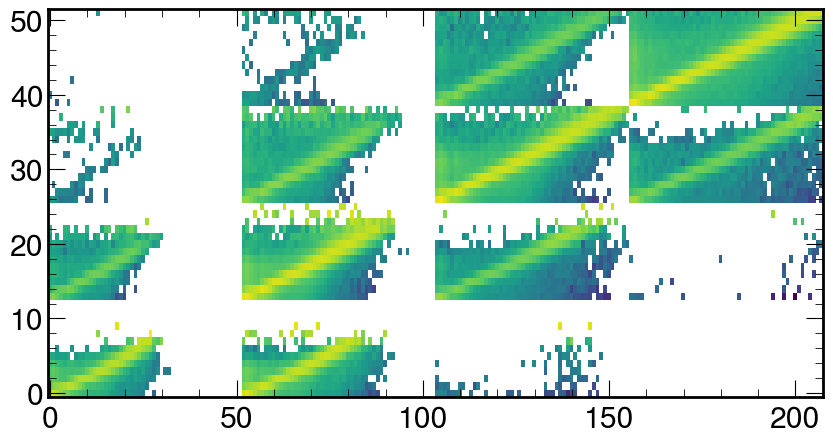

In [12]:
hep.style.use("CMS")
pnp_norm = pnp / np.sum(pnp, axis=1, keepdims=True)
plt.imshow(pnp_norm, origin = 'lower', aspect = rebin_factor_gen/rebin_factor, norm = 'log')

In [17]:
mass_edges_reco = pythia4d.axes['mreco'].edges.tolist()
mass_edges_gen = pythia4d.axes['mgen'].edges.tolist()


In [ ]:
#!/usr/bin/env python3
import random
from array import array
import ROOT as r
import numpy as _np
r.gROOT.SetBatch(True)
random.seed(42)

# ----------------------------
# 1) Define pT slices and mass edges (edit for your analysis)
# ----------------------------
pt_slices = [(0,200.), (200.,290.), (290.,400.), (400.,13000.)]
mreco_edges_pt = [
    mass_edges_reco,  # slice 0
    mass_edges_reco,          # slice 1
    mass_edges_reco,                   # slice 2
    mass_edges_reco,
]
mgen_edges_pt = [
    mass_edges_gen,  # slice 0
    mass_edges_gen,          # slice 1
    mass_edges_gen,                   # slice 2
    mass_edges_gen,   
]
assert len(pt_slices) == len(mreco_edges_pt)

# resolutions (toy)
rel_pt_res = [0.10, 0.08, 0.06]
abs_m_res  = [4.0,  5.0,  6.0]

def find_slice(pt):
    for i,(lo,hi) in enumerate(pt_slices):
        if lo <= pt < hi: return i
    return None

def sample_truth_pt():
    # ~ pT^{-4} between 200 and 1000
    n, pmin, pmax = 4.0, 200.0, 1000.0
    u = random.random()
    a, b = pmin**(1-n), pmax**(1-n)
    return (a + u*(b-a))**(1/(1-n))

def sample_truth_mass(i):
    lo, hi = mass_edges[i][0], mass_edges[i][-1]
    mode, scale = [14.,22.,30.][i], [8.,10.,12.][i]
    for _ in range(1000):
        m = max(0.0, random.expovariate(1.0/scale)) + 0.5*mode
        if lo <= m < hi: return m
    return min(max(mode, lo), hi-1e-6)

def smear_pt(pt,i):   return max(0.0, random.gauss(pt, rel_pt_res[i]*pt))
def smear_m(m,i):     return max(0.0, random.gauss(m,  abs_m_res[i]))

# ----------------------------
# 2) Build binning trees with named nodes
#    truth:  root("truth") -> signal -> pt0,pt1,pt2 (each has "mass" axis)
#    reco :  root("reco")  -> primary -> pt0,pt1,pt2 (each has "mass" axis)
# ----------------------------
truth_root = r.TUnfoldBinning("truth")
reco_root  = r.TUnfoldBinning("reco")

truth_signal = truth_root.AddBinning("signal")
reco_primary = reco_root .AddBinning("primary")

truth_nodes, reco_nodes = [], []
# use separate mass-edge lists for truth (gen) and reco; keep `mass_edges` pointing to gen for sample_truth_mass
mass_edges = mgen_edges_pt

for i in range(len(pt_slices)):
    a_gen  = array('d', mgen_edges_pt[i])
    a_reco = array('d', mreco_edges_pt[i])
    tnode = truth_signal.AddBinning(f"pt{i}")
    rnode = reco_primary.AddBinning(f"pt{i}")
    # 1D mass axis inside each slice; exclude under/overflow bins here
    tnode.AddAxis("mass", len(mgen_edges_pt[i]) - 1, a_gen,  False, False)
    rnode.AddAxis("mass", len(mreco_edges_pt[i]) - 1, a_reco, False, False)
    truth_nodes.append(tnode)
    reco_nodes .append(rnode)

# ----------------------------
# 3) Book histograms consistent with the binning
# ----------------------------
hRecoData   = reco_root .CreateHistogram("hRecoData")    # TH1D over global reco bins
hTruthPrior = truth_root.CreateHistogram("hTruthPrior")  # TH1D over global truth bins
hResponse   = r.TUnfoldBinning.CreateHistogramOfMigrations( truth_root, reco_root, "hResponse")  # TH2D (x=reco, y=truth)

# ----------------------------
# 4) Fill toy MC for response + prior
# ----------------------------
n_mc = 200_000
# fill hResponse from the 4D hist pythia4d (axes: ptgen, mgen, ptreco, mreco)

ptgen_centres = pythia4d.axes['ptgen'].centers
mgen_centres  = pythia4d.axes['mgen'].centers
ptreco_centres= pythia4d.axes['ptreco'].centers
mreco_centres = pythia4d.axes['mreco'].centers
ptgen_centres = np.array([50, 250, 300, 450])
ptreco_centres= np.array([50, 250, 300, 450])
# get values & variances (numpy ndarray with axis order ptgen, mgen, ptreco, mreco)
vals = pythia4d.values(flow = True)
vars_ = pythia4d.variances(flow = True)

for i_ptg, ptg in enumerate(ptgen_centres):
    ig = find_slice(ptg)
    if ig is None: continue
    for i_mg, mg in enumerate(mgen_centres):
        # truth global bin for this pt slice & mass centre
        bT = truth_nodes[ig].GetGlobalBinNumber(array('d', [mg]))
        if bT <= 0: continue

        for i_ptr, ptr in enumerate(ptreco_centres):
            ir = find_slice(ptr)
            if ir is None: continue

            for i_mr, mr in enumerate(mreco_centres):
                val = float(vals[i_ptg, i_mg, i_ptr, i_mr])
                var = float(vars_[i_ptg, i_mg, i_ptr, i_mr])
                if val == 0.0 and var == 0.0:
                    continue

                bR = reco_nodes[ir].GetGlobalBinNumber(array('d', [mr]))
                if bR <= 0: continue

                # try the (ix,iy) overload first, fall back to global bin number if necessary
                try:
                    hResponse.SetBinContent(bT, bR, val)
                    if var > 0.0:
                        hResponse.SetBinError(bT, bR, _np.sqrt(var))
                except TypeError:
                    gbin = hResponse.GetBin(bT, bR)  # global TH2 bin
                    hResponse.SetBinContent(gbin, val)
                    if var > 0.0:
                        hResponse.SetBinError(gbin, _np.sqrt(var))

# ----------------------------
# 5) Fill toy RECO data
# ----------------------------
# fill hRecoData from pythia2d (binned ptreco x mreco)
ptreco_centres = pythia2d.axes['ptreco'].centers
mreco_centres  = pythia2d.axes['mreco'].centers
ptreco_centres= np.array([50, 250, 300, 450])

vals  = herwig4d.values(flow = True)[:-1, 1:-1, :-1, 1:-1].sum(axis=(0,1))  # sum out truth axes -> ptreco x mreco
vars_ = herwig4d.variances(flow = True)[:-1, 1:-1, :-1, 1:-1].sum(axis=(0,1))

vals2  = herwig4d.values(flow = True)[:-1, 1:-1, :-1, 1:-1].sum(axis=(0,1))  # sum out truth axes -> ptreco x mreco
vars2_ = herwig4d.variances(flow = True)[:-1, 1:-1, :-1, 1:-1].sum(axis=(0,1))

gen_vals2  = herwig4d.values(flow = True)[:-1, 1:-1, :-1, 1:-1].sum(axis=(2,3))  # sum out truth axes -> ptreco x mreco
gen_vars2_ = herwig4d.variances(flow = True)[:-1, 1:-1, :-1, 1:-1].sum(axis=(2,3))


if closure:
    vals  = pythia4d.values(flow = True)[:-1, 1:-1, :-1, 1:-1].sum(axis=(0,1))  # sum out truth axes -> ptreco x mreco
    vars_ = pythia4d.variances(flow = True)[:-1, 1:-1, :-1, 1:-1].sum(axis=(0,1))
else:
    vals  = herwig4d.values(flow = True)[:-1, 1:-1, :-1, 1:-1].sum(axis=(0,1))  # sum out truth axes -> ptreco x mreco
    vars_ = herwig4d.variances(flow = True)[:-1, 1:-1, :-1, 1:-1].sum(axis=(0,1))
# hRecoData2 = hRecoData.Clone("hRecoData2")
# hRecoData2.Reset()

for i_ptr, ptr in enumerate(ptreco_centres):
    ir = find_slice(ptr)
    if ir is None:
        continue
    for i_mr, mr in enumerate(mreco_centres):
        val = float(vals[i_ptr, i_mr])
        var = float(vars_[i_ptr, i_mr])

        if val == 0.0 and var == 0.0:
            continue
        bR = reco_nodes[ir].GetGlobalBinNumber(array('d', [mr]))
        if bR <= 0:
            continue
        hRecoData.SetBinContent(bR, val)
        if var > 0.0:
            hRecoData.SetBinError(bR, _np.sqrt(var))

# ----------------------------
# 6) Construct TUnfoldDensity with full argument list
#     - EHistMap: kHistMapOutputHoriz  (x=reco, y=truth)
#     - Regularise only the 'signal' truth distribution
#     - Axis steering: *[UOB]  (drop under/overflow; bin-width aware derivatives)
# ----------------------------
unfold = r.TUnfoldDensity(
    hResponse,
    r.TUnfold.kHistMapOutputHoriz,          # mapping of TH2 axes
    r.TUnfold.kRegModeDerivative,            # curvature regularisation
    r.TUnfold.kEConstraintArea,             # one global area constraint
    r.TUnfoldDensity.kDensityModeBinWidthAndUser,  # bin-width aware scaling
    truth_root,                              # output (truth) binning tree
    reco_root,                               # input  (reco)  binning tree
    "signal",                                # regularisationDistributionName
    "*[UOB]"                                 # regularisationAxisSteering
)

# Provide input and bias
unfold.SetInput(hRecoData, 1.0)
#unfold.SetBias(hTruthPrior)

unfold.DoUnfold(0.0)

# ----------------------------
# 7) Retrieve outputs & diagnostics
# ----------------------------



0.9947138019938233

Warning in <TROOT::Append>: Replacing existing TH1: hRecoData (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hTruthPrior (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hResponse (Potential memory leak).
Info in <TUnfold::SetConstraint>: fConstraint=1
Warning in <TUnfold::TUnfold>: 18 output bins do not depend on the input data  0-13 24-26 53
Info in <TUnfold::TUnfold>: 208 input bins and 36 output bins
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #0
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #1 (pt0:mass[0,8])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #2 (pt0:mass[8,22])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #3 (pt0:mass[22,38])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #4 (pt0:mass[38,54])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #5 (pt0:mass[54,70])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #6 (pt0:mass[70,86])
Info in <TUnfoldDensity

In [19]:

# np.linalg.cond(pnp_norm)

In [20]:
c = r.TCanvas('c','c',800,600)
hRecoData.Draw('E')
y = hResponse.ProjectionY()

y.Draw('same')
c.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


In [21]:
# c2 = r.TCanvas('c2','c2',800,600)
# hRecoData.Draw('E')
# y = hResponse.ProjectionY()

# y.Draw('same')
# c2.Draw()

In [22]:
output = unfold.GetOutput('h')
rp = unfold.GetProbabilityMatrix('rp')
c_rp = r.TCanvas('c_rp', 'rp', 900, 700)
c_rp.SetRightMargin(0.18)
rp.SetTitle('Response probability matrix (rp);reco global bin;truth global bin')
rp.Draw('COLZ')
c_rp.SetLogz()
c_rp.Draw()

Warning in <TUnfoldBinning::CreateHistogram>: Original binning can not be represented as THxx


In [42]:
c1 = r.TCanvas('c','c',800,600)

y = hResponse.ProjectionX()
output.SetLineColor(r.kRed)
output.Draw('same')
y.Draw('same')
c1.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


Mass edges: [0.0, 10.0, 30.0, 50.0, 70.0, 90.0, 110.0, 130.0, 150.0, 170.0, 190.0]
Extracted 40 bins: arrays vals2 (values), vals2_err (errors), vals2_centers, vals2_edges


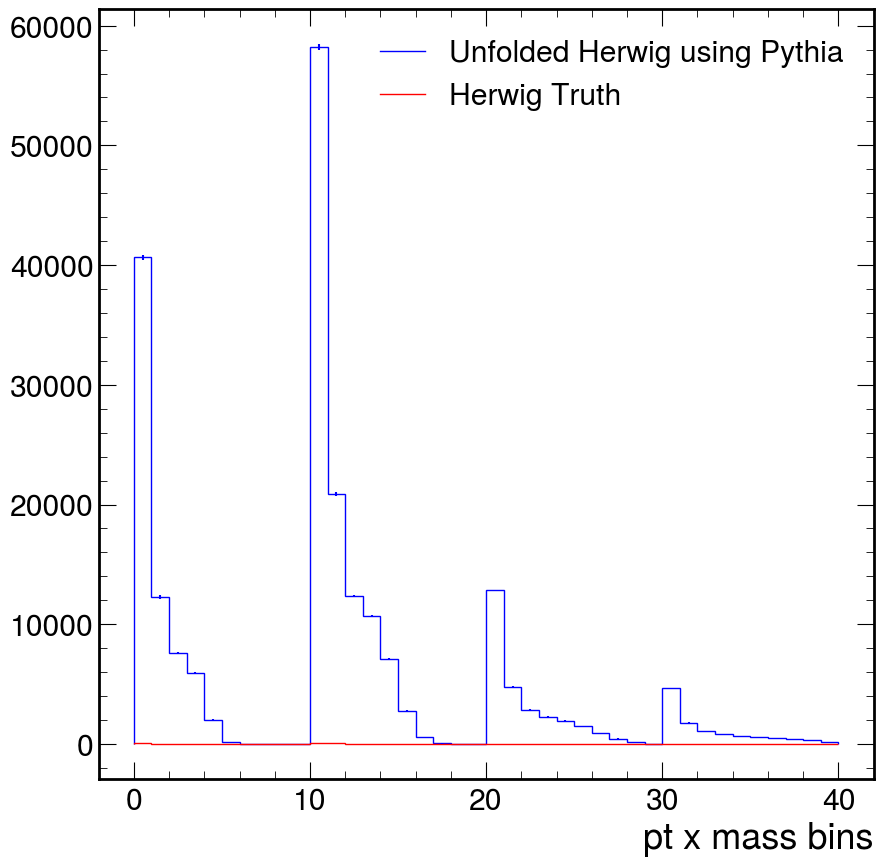

/tmp/ipykernel_268159/2956256370.py:31: RuntimeWarning: divide by zero encountered in divide
  plt.stairs(np.abs(vals2 - gen_vals2.flatten())/gen_vals2.flatten(), label = 'Difference', color = 'g')
/tmp/ipykernel_268159/2956256370.py:31: RuntimeWarning: invalid value encountered in divide
  plt.stairs(np.abs(vals2 - gen_vals2.flatten())/gen_vals2.flatten(), label = 'Difference', color = 'g')


Text(0, 1, 'Relative Uncertainty')

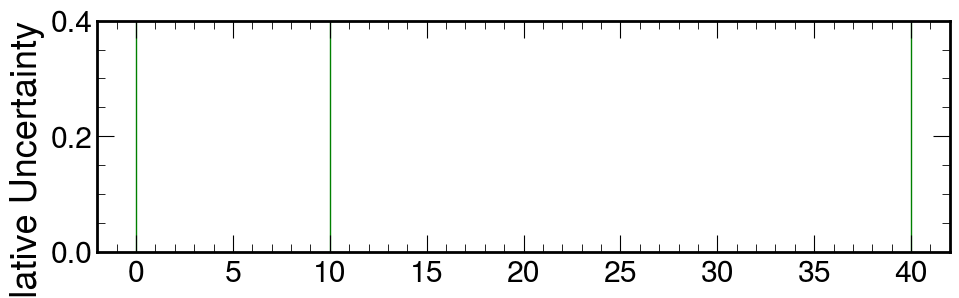

In [43]:
# extract TH1D 'output' into numpy arrays
if 'output' not in globals():
    raise NameError("Histogram 'output' not found in globals()")

nbins = int(output.GetNbinsX())

edges = np.array([output.GetXaxis().GetBinLowEdge(i) for i in range(1, nbins + 2)])
centers = np.array([output.GetXaxis().GetBinCenter(i) for i in range(1, nbins + 1)])
values = np.array([output.GetBinContent(i) for i in range(1, nbins + 1)])
errors = np.array([output.GetBinError(i) for i in range(1, nbins + 1)])
print("Mass edges:", mgen_edges_pt[0])

# convenience container
vals2 = values  # keep name requested by the notebook if desired
vals2_edges = edges
vals2_centers = centers
vals2_err = errors

print(f"Extracted {nbins} bins: arrays vals2 (values), vals2_err (errors), vals2_centers, vals2_edges")

plt.stairs(vals2, label = 'Unfolded Herwig using Pythia', color = 'b')
    

plt.errorbar(np.arange(vals2_centers.size)+0.5, vals2, yerr=vals2_err, fmt='none', ecolor='b', capsize=0)
plt.stairs(gen_vals2.flatten(), label = "Herwig Truth", color = 'r')
plt.errorbar(np.arange(vals2_centers.size)+0.5, gen_vals2.flatten(), yerr=np.sqrt(gen_vars2_.flatten()), fmt='none', ecolor='r', capsize=0)
plt.legend()
plt.xlabel("pt x mass bins")
plt.show()
plt.figure(figsize=(11,3))
plt.stairs(np.abs(vals2 - gen_vals2.flatten())/gen_vals2.flatten(), label = 'Difference', color = 'g')
plt.ylim(0,0.4)
plt.ylabel("Relative Uncertainty")

In [44]:
# use TH1::Clone to duplicate (provide a new name)
output_rebinned = output.Clone("output_rebinned")
y_rebinned = y.Clone("y_rebinned")
y_rebinned.Rebin(2)
output_rebinned.Rebin(2)
c3 = r.TCanvas('c3','c3',800,600)
output_rebinned.SetLineColor(r.kRed)
output_rebinned.Draw('E')
y_rebinned.Draw('same')
c3.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c3


In [29]:
rebin_factors = [ 5, 10]
loaded_outputs = {}
for rf in rebin_factors:
    with np.load(f"herwig_output_{rf}.npz") as data:
        loaded_outputs[rf] = {key: data[key] for key in data.files}

fig, ax = plt.subplots(figsize=(8, 5))
for rf in rebin_factors:
    unfolded = loaded_outputs[rf]["unfolded"]
    unfolded_err = loaded_outputs[rf]["unfolded_err"]
    bins = np.arange(len(unfolded))
    ax.errorbar(
        bins,
        unfolded,
        yerr=unfolded_err,
        label=f"Herwig rebin {rf}",
        marker="o",
        linestyle="-",
        capsize=2,
    )

ax.set_xlabel("Unfolded bin")
ax.set_ylabel("Entries")
ax.set_title("Herwig unfolded comparison")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()


FileNotFoundError: [Errno 2] No such file or directory: 'herwig_output_5.npz'